In [156]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../..')))

In [157]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

from deepthinking.models import dt_net_recall_2d

Device: cuda


In [158]:
checkpoint = torch.load('../outputs/mazes_ablation/training-rusty-Tayla/model_best.pth', map_location=device)

model = dt_net_recall_2d(width=128, in_channels=3, max_iters=30)

state_dict = checkpoint['net']
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)
model = model.to(device)
model.eval()
print("Model loaded!")

Model loaded!


In [159]:
print(model)

DTNet(
  (projection): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU()
  )
  (recur_block): Sequential(
    (0): Conv2d(131, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Sequential(
      (0): BasicBlock2D(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn1): Sequential()
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn2): Sequential()
        (shortcut): Sequential()
      )
      (1): BasicBlock2D(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn1): Sequential()
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn2): Sequential()
        (shortcut): Sequential()
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(128, 32, kernel_size=(3, 3), stride=(1,

In [160]:
# Load data
x_np = np.load('../data/maze_data_test_9/inputs.npy')
y_np = np.load('../data/maze_data_test_9/solutions.npy')

print(f"Inputs shape: {x_np.shape}")
print(f"Solutions shape: {y_np.shape}")
print(f"Input range: [{x_np.min()}, {x_np.max()}]")
print(f"Solution range: [{y_np.min()}, {y_np.max()}]")
print(f"Solution unique values: {np.unique(y_np)}")

Inputs shape: (10000, 32, 32, 3)
Solutions shape: (10000, 32, 32, 3)
Input range: [0.0, 1.0]
Solution range: [0.0, 1.0]
Solution unique values: [0. 1.]


In [161]:
idx = 333
maze_input = x_np[idx]  # (H, W, 3)
ground_truth_rgb = y_np[idx]  # (H, W, 3)

print(f"Maze input shape: {maze_input.shape}")
print(f"Ground truth shape: {ground_truth_rgb.shape}")

Maze input shape: (32, 32, 3)
Ground truth shape: (32, 32, 3)


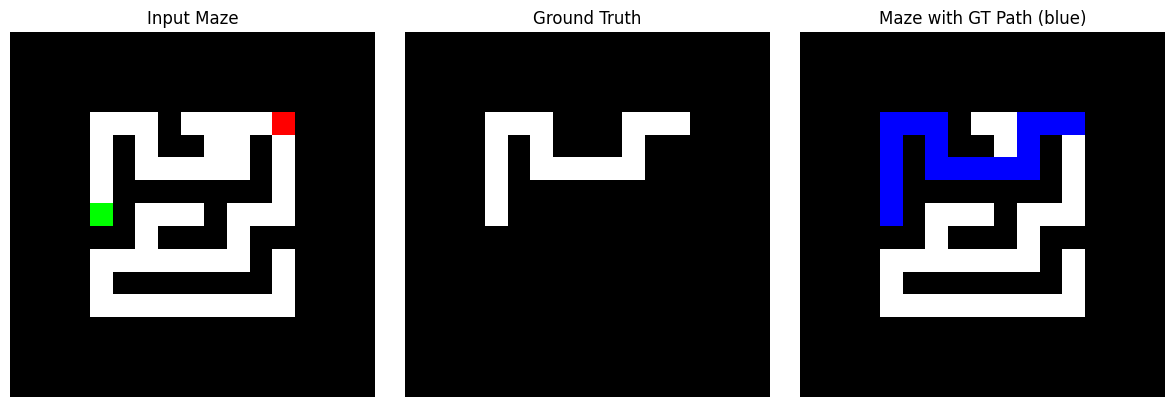

In [162]:
# Plot input and ground truth
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(maze_input)
axes[0].set_title('Input Maze')
axes[0].axis('off')

axes[1].imshow(ground_truth_rgb)
axes[1].set_title('Ground Truth')
axes[1].axis('off')

# Overlay: show path on maze
overlay = maze_input.copy()
path_mask = ground_truth_rgb[:,:,0] > 0.5
overlay[path_mask] = [0, 0, 1]  # blue for path
axes[2].imshow(overlay)
axes[2].set_title('Maze with GT Path (blue)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [163]:
def get_maze_prediction(output, input_tensor):
    """
    Get maze path prediction.
    """
    if output.dim() == 4:
        output = output[0]
    if input_tensor.dim() == 4:
        input_tensor = input_tensor[0]
    
    # argmax over channels (1 where Ch1 > Ch0)
    predicted = output.argmax(dim=0)
    
    # Mask with walkable area
    walkable = input_tensor.max(dim=0)[0]
    
    # Multiply to get final prediction
    predicted = predicted.float() * walkable
    
    return predicted

In [164]:
# %%
# Prepare input tensor
x = torch.tensor(maze_input, dtype=torch.float32).unsqueeze(0)  # (1, H, W, 3)
x = x.permute(0, 3, 1, 2)  # (1, 3, H, W)
x = x.to(device)
print(f"Input tensor shape: {x.shape}")

with torch.no_grad():
    # Use model's built-in forward
    output = model(x, iters_to_do=30)

print(f"Output type: {type(output)}")
print(f"Output shape: {output.shape}")  # (B, T, C, H, W) = (1, 30, 2, 32, 32)
print(f"Output range: [{output.min():.4f}, {output.max():.4f}]")

Input tensor shape: torch.Size([1, 3, 32, 32])
Output type: <class 'torch.Tensor'>
Output shape: torch.Size([1, 30, 2, 32, 32])
Output range: [-9.9322, 9.6247]


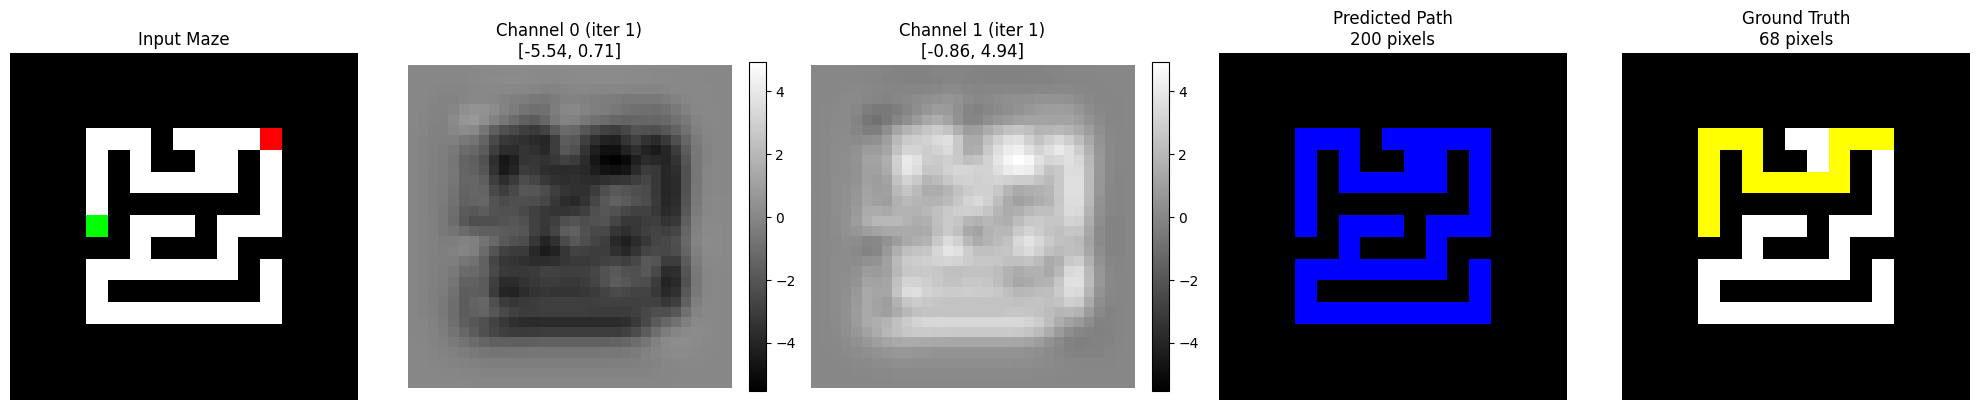

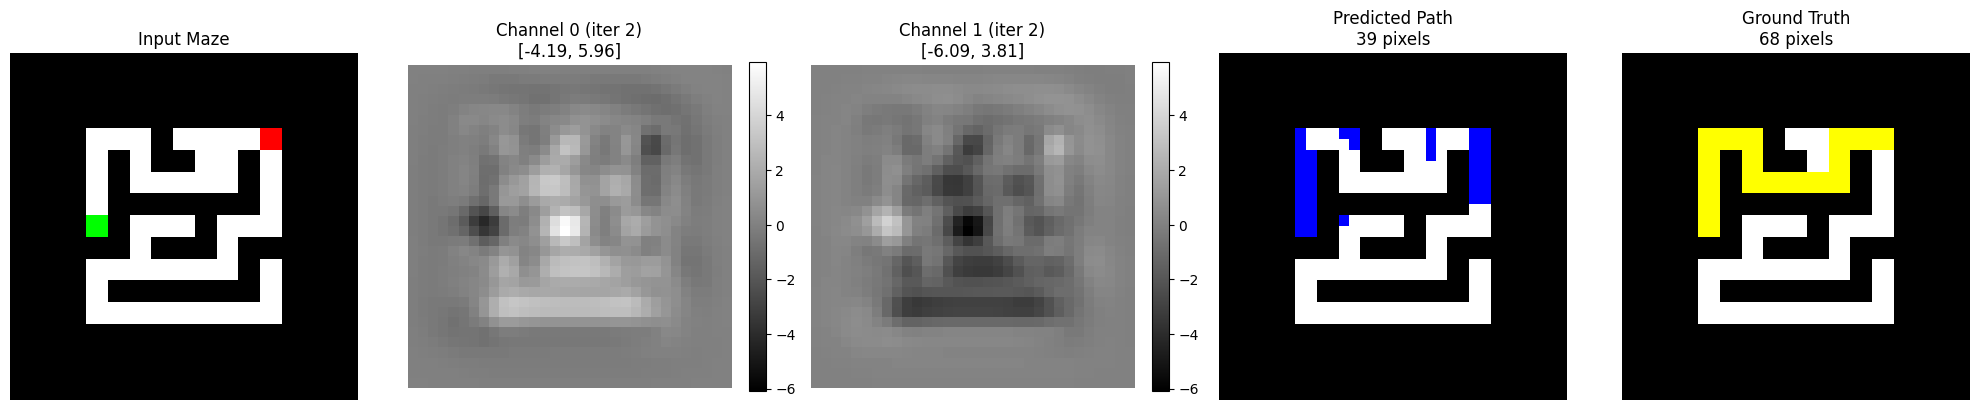

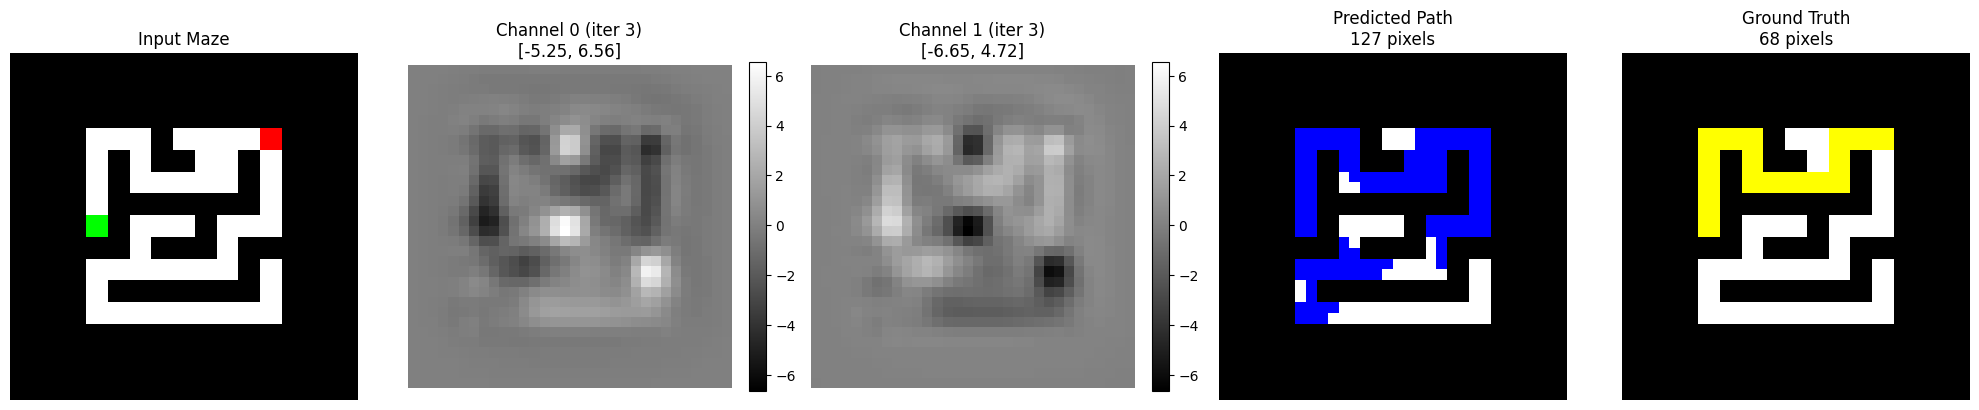

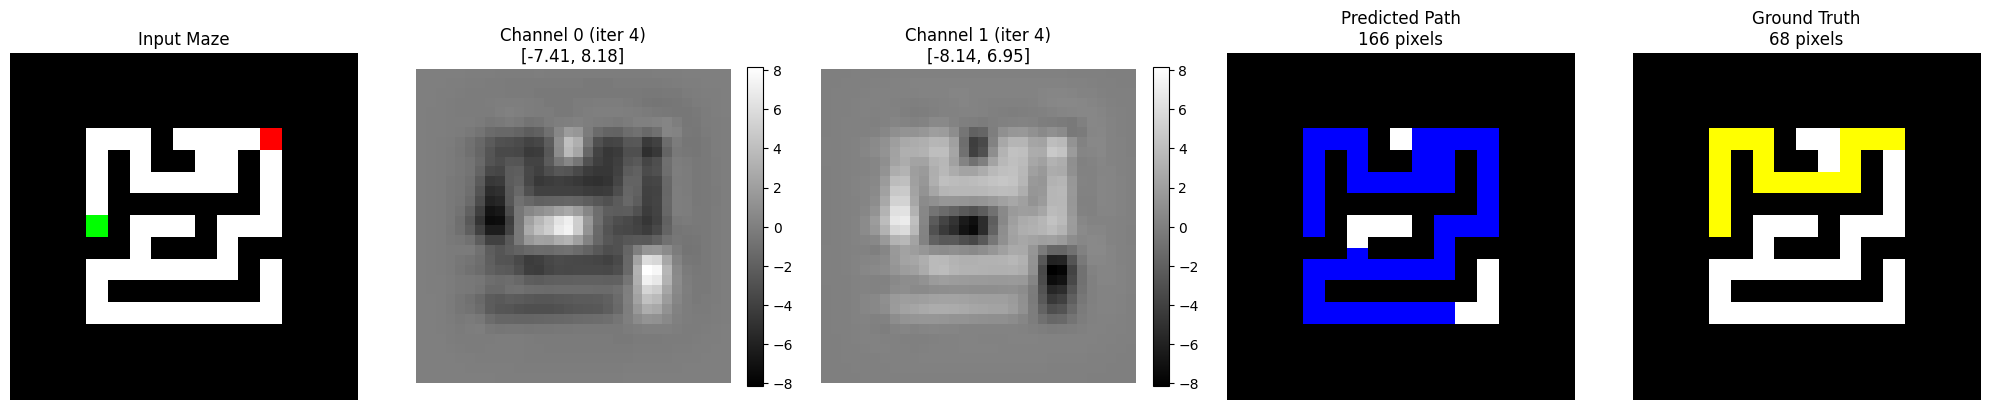

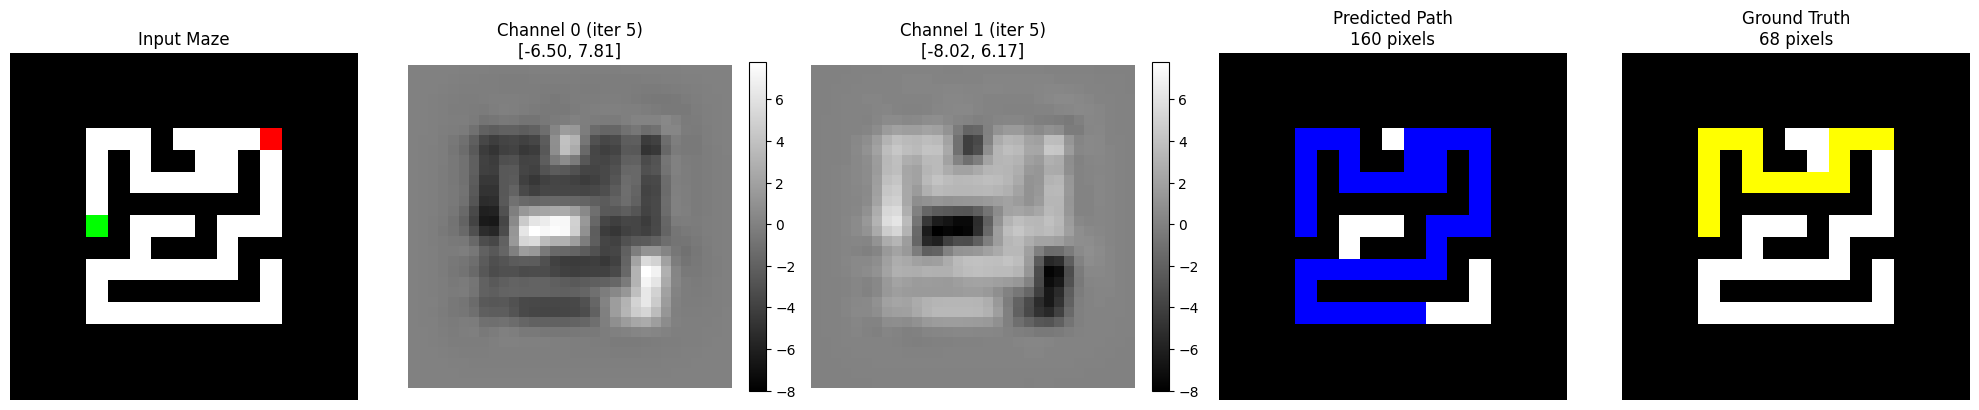

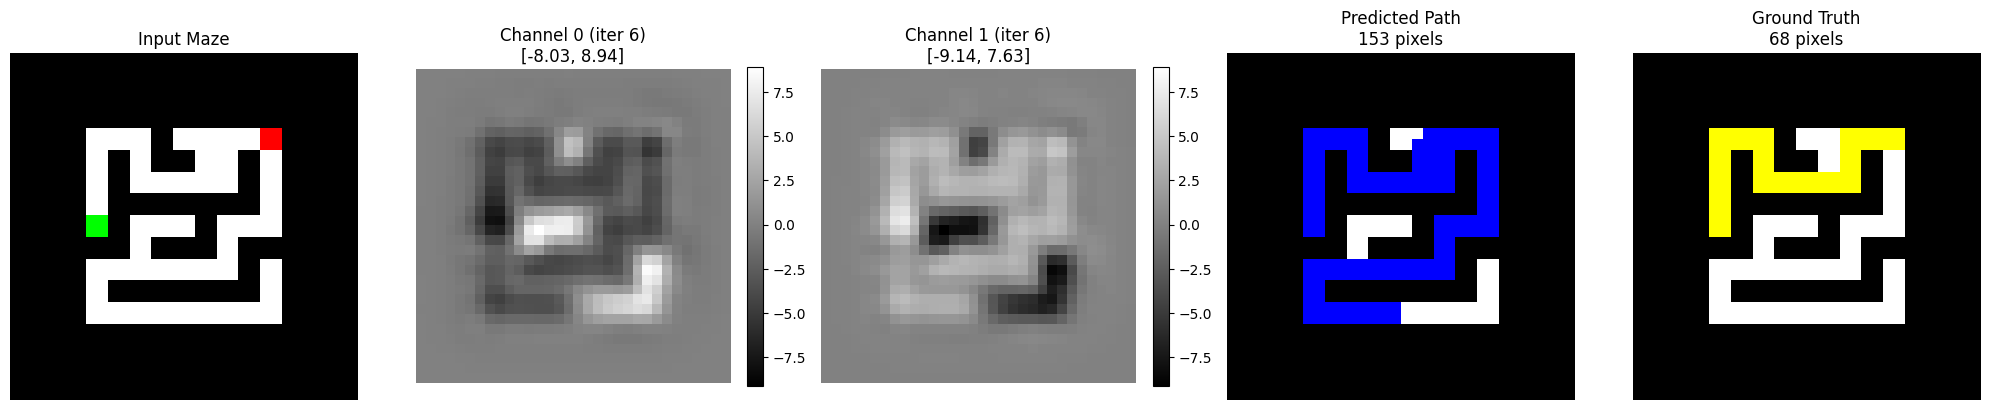

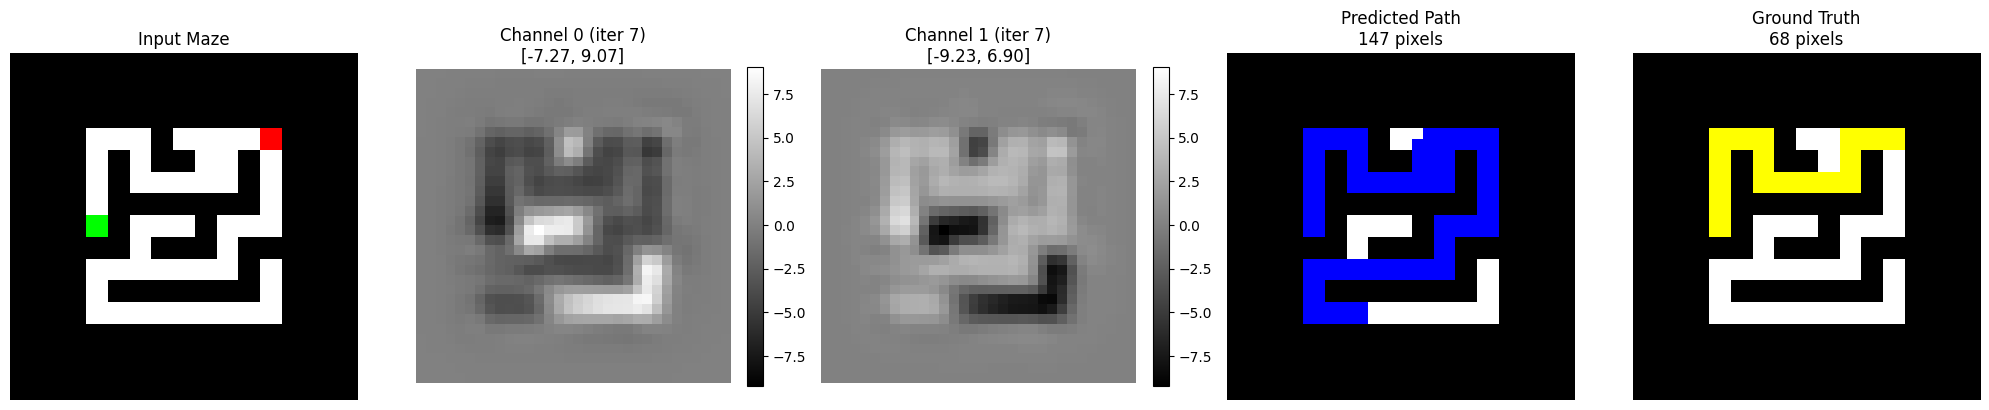

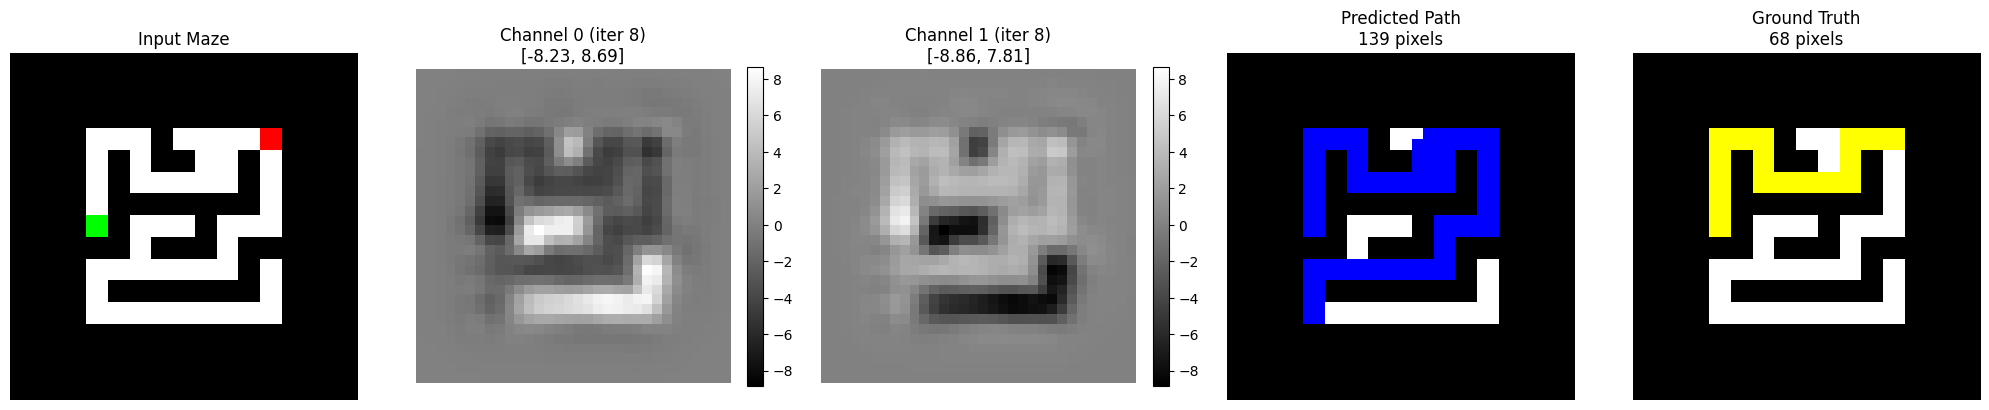

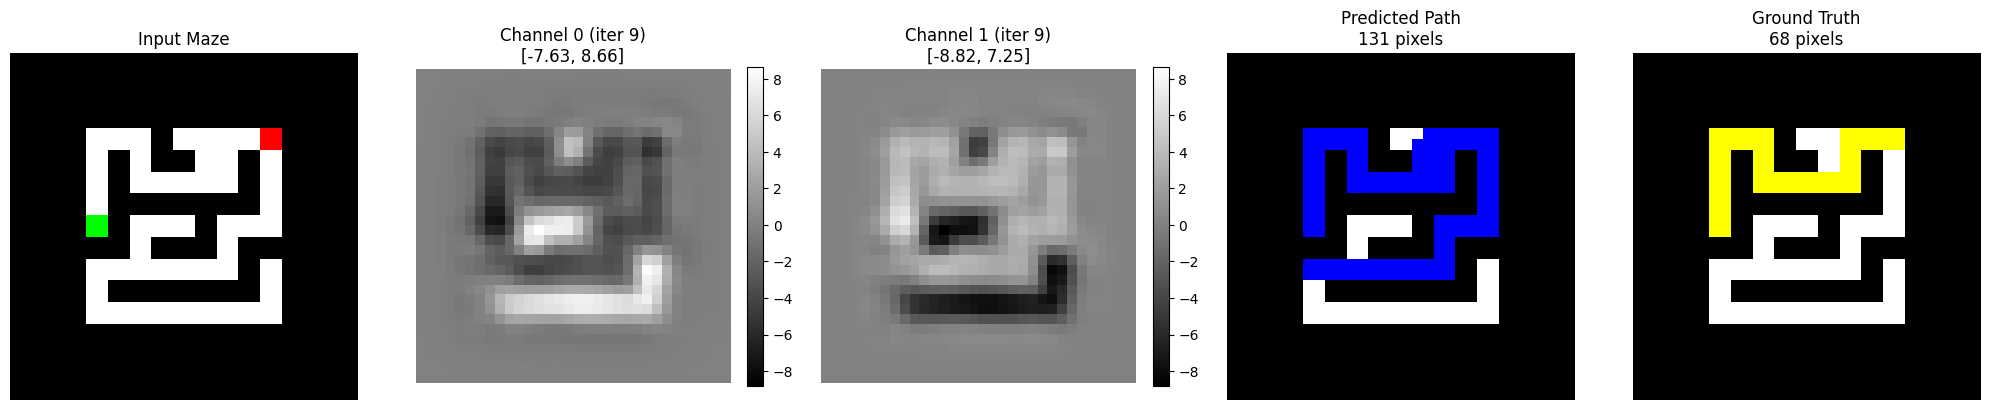

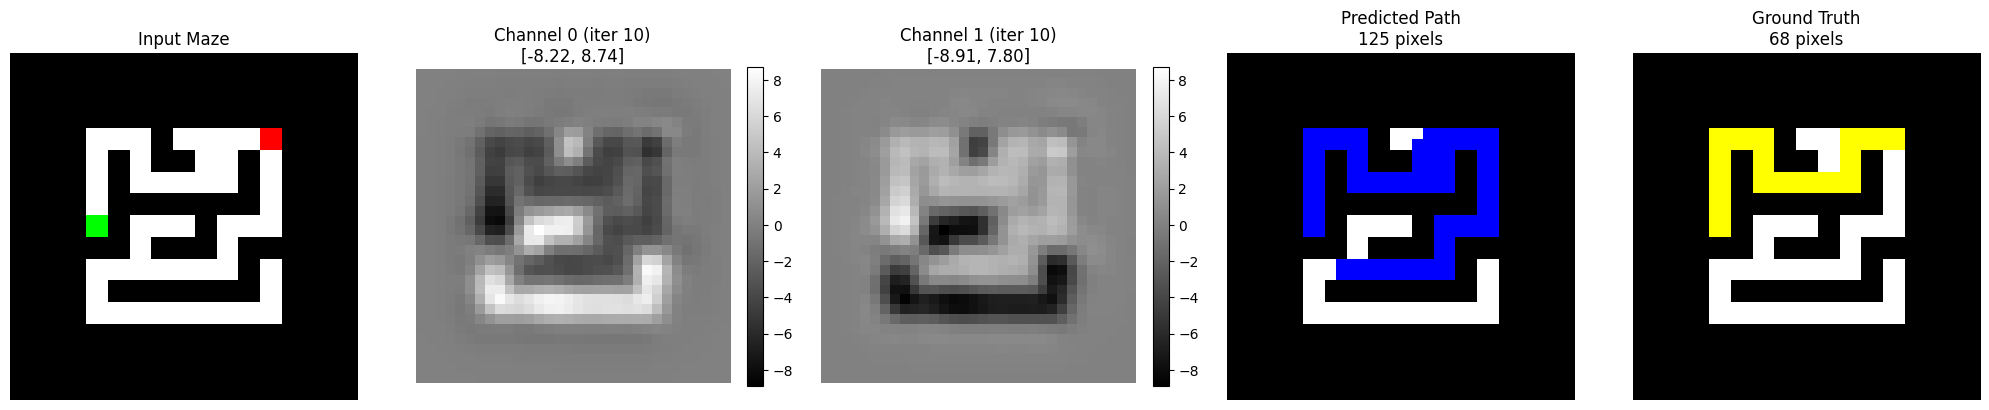

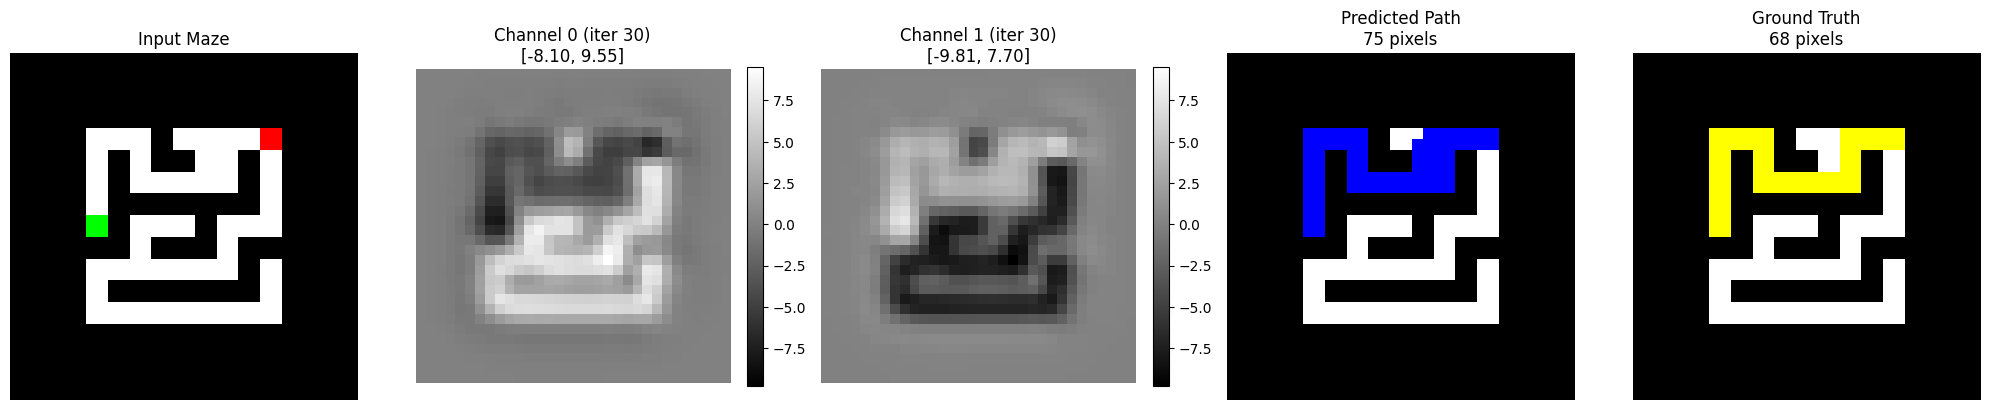

In [165]:
for it in [0,1,2,3,4,5,6,7,8,9,29]:
    iter_output = output[0, it]  # (C, H, W) - last iteration

    iter_output_np = iter_output.cpu().numpy()
    vmin = min(iter_output_np[0].min(), iter_output_np[1].min())
    vmax = max(iter_output_np[0].max(), iter_output_np[1].max())

    pred_path = get_maze_prediction(iter_output, x).cpu().numpy()

    # %%
    # Plot the two output channels for final iteration
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(maze_input)
    axes[0].set_title('Input Maze')
    axes[0].axis('off')

    im0 = axes[1].imshow(iter_output_np[0], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].set_title(f'Channel 0 (iter {it+1})\n[{iter_output_np[0].min():.2f}, {iter_output_np[0].max():.2f}]')
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046)

    im1 = axes[2].imshow(iter_output_np[1], cmap='gray', vmin=vmin, vmax=vmax)
    axes[2].set_title(f'Channel 1 (iter {it+1})\n[{iter_output_np[1].min():.2f}, {iter_output_np[1].max():.2f}]')
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046)

    # Predicted path overlay on maze
    vis_pred = maze_input.copy()
    path_mask = pred_path > 0.5
    vis_pred[path_mask] = [0.0, 0.0, 1.0]  # Blue for predicted path
    axes[3].imshow(vis_pred)
    axes[3].set_title(f'Predicted Path\n{int(path_mask.sum())} pixels')
    axes[3].axis('off')

    # Ground truth overlay on maze
    vis_gt = maze_input.copy()
    gt_mask = ground_truth_rgb[:,:,0] > 0.5
    vis_gt[gt_mask] = [1.0, 1.0, 0.0]  # Green for GT path
    axes[4].imshow(vis_gt)
    axes[4].set_title(f'Ground Truth\n{int(gt_mask.sum())} pixels')
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()